# Guia de Análise Exploratória de Dados (EDA) - Dataset IMDB (https://www.kaggle.com/datasets/adriankiezun/imdb-dataset-2023)

Este notebook traz um guia para realizar uma análise completa de dados de filmes, explorando distribuições, correlações, tendências temporais e características de filmes de sucesso.

## Objetivos da Análise

1. Compreender a estrutura e qualidade dos dados
2. Tratar valores ausentes e inconsistências
3. Explorar distribuições de variáveis numéricas
4. Analisar correlações entre variáveis
5. Investigar padrões temporais de lançamentos
6. Avaliar o desempenho financeiro dos filmes (ROI)

---

## Tarefa 1: Importação das Bibliotecas

**Objetivo:** Importar todas as bibliotecas necessárias para a análise.

**O que você precisa fazer:**

1. Importe a biblioteca `numpy` com o alias `np` - para operações numéricas
2. Importe a biblioteca `pandas` com o alias `pd` - para manipulação de dataframes
3. Importe a biblioteca `seaborn` com o alias `sns` - para visualizações estatísticas
4. Importe a biblioteca `matplotlib.pyplot` com o alias `plt` - para gráficos

**Dica:** Use o comando `import` seguido do nome da biblioteca e `as` para definir o alias.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

---

## Tarefa 2: Carregamento dos Dados

**Objetivo:** Carregar o dataset IMDB em um DataFrame pandas.

**O que você precisa fazer:**

1. Use a função do pandas para ler arquivos CSV
2. O arquivo está localizado em: `imdb_data.csv` (no mesmo diretório deste notebook)
3. Armazene o resultado em uma variável chamada `df`

**Função a usar:** `pd.read_csv()`

**Parâmetros:**
- **filepath**: caminho para o arquivo CSV (pode ser relativo ou absoluto)

**Dica:** Se estiver no mesmo diretório, basta passar o nome do arquivo entre aspas.

In [6]:
df=pd.read_csv("imdb_data.csv")

---

## Tarefa 3: Inspeção Inicial dos Dados

**Objetivo:** Conhecer a estrutura do dataset, tipos de dados e informações básicas.

**O que você precisa fazer:**

1. Use o método que mostra informações gerais do DataFrame (tipos de dados, quantidade de valores não-nulos, uso de memória)

**Método a usar:** `.info()`

**Parâmetros:** Nenhum parâmetro necessário

**O que observar:**
- Quantas linhas e colunas existem?
- Quais são os tipos de dados de cada coluna?
- Há colunas com valores ausentes (não-null count menor que o total)?

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3348 entries, 0 to 3347
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              3348 non-null   object 
 1   primaryTitle    3348 non-null   object 
 2   originalTitle   3348 non-null   object 
 3   isAdult         3348 non-null   int64  
 4   runtimeMinutes  3348 non-null   int64  
 5   genres          3348 non-null   object 
 6   averageRating   3348 non-null   float64
 7   numVotes        3348 non-null   int64  
 8   budget          3348 non-null   int64  
 9   gross           3297 non-null   float64
 10  release_date    3343 non-null   object 
 11  directors       3348 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 314.0+ KB


---

## Tarefa 4: Identificação de Valores Ausentes

**Objetivo:** Quantificar valores ausentes (NaN/null) em cada coluna.

**O que você precisa fazer:**

1. Use o método que identifica valores nulos no DataFrame
2. Em seguida, conte quantos valores nulos existem em cada coluna

**Métodos a usar:**
- `.isnull()` - identifica valores nulos (retorna True/False)
- `.sum()` - soma os valores True (que equivalem a 1)

**Dica:** Você pode encadear os dois métodos: `df.isnull().sum()`

**O que observar:**
- Quais colunas têm valores ausentes?
- Qual é a proporção de valores ausentes em cada coluna?

In [8]:
df.isnull().sum()
df.isnull().mean()

,0
id,0.000000
primaryTitle,0.000000
originalTitle,0.000000
isAdult,0.000000
runtimeMinutes,0.000000
genres,0.000000
averageRating,0.000000
numVotes,0.000000
budget,0.000000
gross,0.015233


---

## Tarefa 5: Tratamento de Valores Ausentes

**Objetivo:** Tratar valores ausentes nas colunas `release_date` e `gross`.

### Parte A: Tratamento da coluna `release_date`

**O que você precisa fazer:**

1. Converta a coluna `release_date` para o tipo datetime
2. Remova as linhas com datas ausentes

**Funções a usar:**

**Passo 1:** Converter para datetime
- Função: `pd.to_datetime()`
- Parâmetros:
  - `arg`: a coluna a ser convertida (`df['release_date']`)
  - `errors='coerce'`: converte valores inválidos para NaT (Not a Time)

**Passo 2:** Remover linhas com datas ausentes
- Método: `.dropna()`
- Parâmetros:
  - `subset=['release_date']`: remove apenas linhas onde `release_date` é nulo
  - `inplace=True`: modifica o DataFrame original (ou reatribua: `df = df.dropna(...)`)

**Dica:** Você pode fazer: `df = df.dropna(subset=['release_date'])`

### Parte B: Tratamento da coluna `gross`

**O que você precisa fazer:**

1. Preencha os valores ausentes com a mediana da coluna

**Por que mediana?** A mediana é menos sensível a outliers e representa melhor distribuições assimétricas.

**Métodos a usar:**
- `.median()`: calcula a mediana da coluna
- `.fillna()`: preenche valores ausentes

**Parâmetros do fillna:**
- `value`: o valor para preencher (no caso, a mediana calculada)

**Dica:** Você pode fazer em uma linha: `df['gross'].fillna(df['gross'].median())`

In [9]:
# Parte A
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df = df.dropna(subset=['release_date'])

# Parte B
df['gross'] = df['gross'].fillna(df['gross'].median())


---

## Tarefa 6: Verificação Pós-Tratamento

**Objetivo:** Confirmar que os valores ausentes foram tratados corretamente.

**O que você precisa fazer:**

1. Repita a contagem de valores nulos (mesmo procedimento da Tarefa 4)

**Resultado esperado:** A contagem de valores nulos deve ter diminuído ou zerado nas colunas tratadas.

In [10]:
df.isnull().sum()

,0
id,0
primaryTitle,0
originalTitle,0
isAdult,0
runtimeMinutes,0
genres,0
averageRating,0
numVotes,0
budget,0
gross,0


---

## Tarefa 7: Visualização Geral dos Dados

**Objetivo:** Visualizar as primeiras linhas do DataFrame para entender o conteúdo.

**O que você precisa fazer:**

1. Exiba o DataFrame completo (ou use um método para visualizar as primeiras/últimas linhas)

**Métodos úteis:**
- `df` - exibe o DataFrame (com truncamento automático se for muito grande)
- `.head(n)` - exibe as primeiras n linhas
- `.tail(n)` - exibe as últimas n linhas

**Parâmetros:**
- `n`: número de linhas a exibir (padrão é 5)

In [11]:
df.head()


,id,primaryTitle,originalTitle,isAdult,runtimeMinutes,genres,averageRating,numVotes,budget,gross,release_date,directors
0,tt0035423,Kate & Leopold,Kate & Leopold,0,118,"Comedy,Fantasy,Romance",6.4,87925,48000000,76019048.0,2001-12-11,James Mangold
1,tt0065421,The Aristocats,The AristoCats,0,78,"Adventure,Animation,Comedy",7.1,111758,4000000,35459543.0,1970-12-11,Wolfgang Reitherman
2,tt0065938,Kelly's Heroes,Kelly's Heroes,0,144,"Adventure,Comedy,War",7.6,52628,4000000,5200000.0,1970-01-01,Brian G. Hutton
3,tt0066026,M*A*S*H,M*A*S*H,0,116,"Comedy,Drama,War",7.4,75784,3500000,81600000.0,1970-01-25,Robert Altman
4,tt0066206,Patton,Patton,0,172,"Biography,Drama,War",7.9,106476,12000000,61749765.0,1970-02-04,Franklin J. Schaffner


---

## Tarefa 8: Matriz de Correlação

**Objetivo:** Calcular e visualizar as correlações entre variáveis numéricas.

### Contexto: O que é correlação?
A correlação mede a força e direção da relação linear entre duas variáveis:
- **+1**: correlação positiva perfeita
- **0**: sem correlação
- **-1**: correlação negativa perfeita

**O que você precisa fazer:**

**Passo 1:** Selecionar as colunas numéricas
- Selecione as colunas: `'runtimeMinutes'`, `'averageRating'`, `'numVotes'`, `'budget'`, `'gross'`
- Armazene em `colunas_numericas`

**Passo 2:** Calcular a matriz de correlação
- Use o método `.corr()` nas colunas selecionadas
- Armazene em `matriz_correlacao`

**Passo 3:** Configurar o tamanho da figura
- Use `plt.figure(figsize=(10, 6))`

**Passo 4:** Criar o heatmap (mapa de calor)
- Função: `sns.heatmap()`
- Parâmetros principais:
  - Primeiro parâmetro: a matriz de correlação
  - `annot=True`: mostra os valores nas células
  - `cmap='coolwarm'`: esquema de cores (azul para negativo, vermelho para positivo)

**Passo 5:** Adicionar título e exibir
- `plt.title()`: 'Matriz de Correlação'
- `plt.show()`: exibe o gráfico

**O que observar:**
- Quais variáveis têm correlação forte (próximo de +1 ou -1)?
- Há alguma correlação surpreendente?

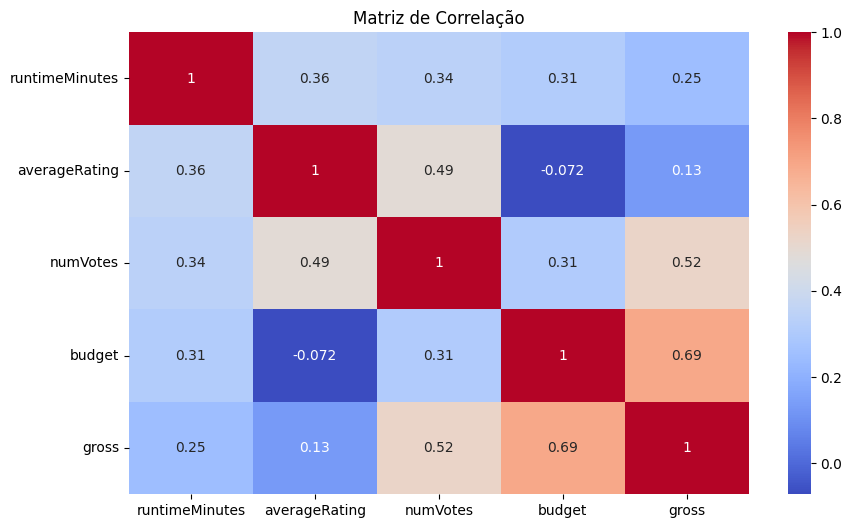

In [12]:
# Passo 1
colunas_numericas = df[['runtimeMinutes', 'averageRating', 'numVotes', 'budget', 'gross']]

# Passo 2
matriz_correlacao = colunas_numericas.corr()

# Passo 3
plt.figure(figsize=(10, 6))

# Passo 4
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm')

# Passo 5
plt.title('Matriz de Correlação')
plt.show()


---

## Tarefa 9: Análise de Gêneros Únicos

**Objetivo:** Identificar e contar quantos gêneros únicos existem no dataset.

### Contexto:
A coluna `genres` contém múltiplos gêneros separados por vírgula (ex: "Action,Adventure,Sci-Fi"). Precisamos separar esses gêneros para contá-los individualmente.

**O que você precisa fazer:**

**Passo 1:** Separar os gêneros e explodir em linhas individuais
- Método: `.str.split()` na coluna `genres`
- Parâmetros:
  - `sep=','`: separador é a vírgula
- Em seguida, use `.explode()` para criar uma linha para cada gênero
- Por fim, use `.unique()` para obter apenas valores únicos

**Passo 2:** Contar e exibir
- Use `len()` para contar quantos gêneros únicos existem
- Use `print()` para exibir a quantidade e a lista de gêneros

**Dica:** Você pode encadear os métodos: `df['genres'].str.split(',').explode().unique()`

**Armazene o resultado em uma variável chamada `generos`**

In [13]:
# Passo 1
generos = df['genres'].str.split(',').explode().unique()

# Passo 2 e 3
print("Quantidade de gêneros únicos:", len(generos))
print("Lista de gêneros:", generos)


Quantidade de gêneros únicos: 22
Lista de gêneros: ['Comedy' 'Fantasy' 'Romance' 'Adventure' 'Animation' 'War' 'Drama'
 'Biography' 'Sci-Fi' 'Thriller' 'Crime' 'Action' 'Family' 'Musical'
 'Music' 'Mystery' 'Western' 'Horror' 'History' 'Sport' 'Documentary'
 'News']


---

## Tarefa 10: Distribuição das Notas Médias

**Objetivo:** Visualizar como as notas médias dos filmes estão distribuídas.

**O que você precisa fazer:**

**Passo 1:** Configurar o tamanho da figura
- Função: `plt.figure()`
- Parâmetros:
  - `figsize=(10, 6)`

**Passo 2:** Criar um histograma com curva de densidade (KDE)
- Função: `sns.histplot()`
- Parâmetros:
  - `data`: a coluna de notas médias sem valores nulos (`df['averageRating'].dropna()`)
  - `kde=True`: adiciona a curva de densidade estimada
  - `bins=20`: divide os dados em 20 intervalos

**Passo 3:** Adicionar título e rótulos
- `plt.title()`: 'Distribuição da Média das Notas'
- `plt.xlabel()`: 'Nota Média'
- `plt.ylabel()`: 'Frequência'

**Passo 4:** Configurar marcas do eixo X
- Função: `plt.xticks()`
- Parâmetros:
  - `ticks=np.arange(0, 10.5, 0.5)`: de 0 a 10.5 com intervalo de 0.5

**Passo 5:** Exibir o gráfico
- Função: `plt.show()`

**O que observar:**
- Qual é o valor mais comum de nota média?
- A distribuição é simétrica ou assimétrica?

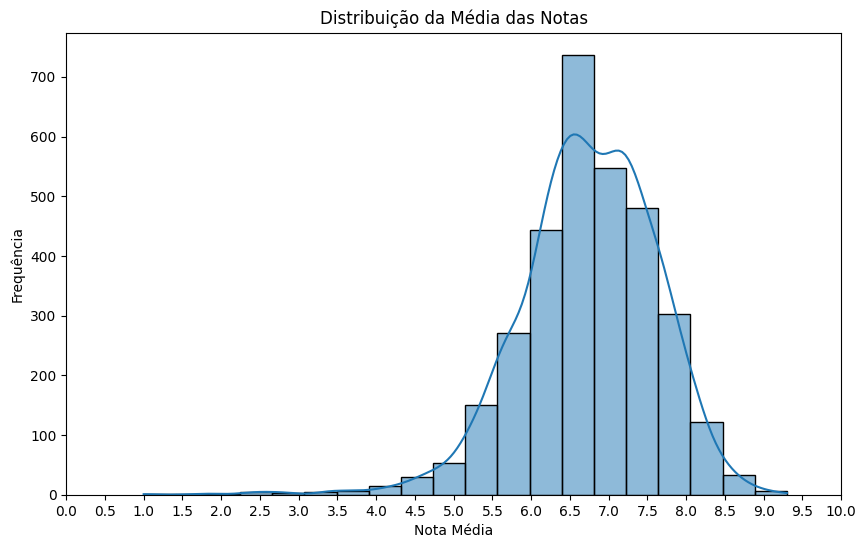

In [14]:
# Passo 1
plt.figure(figsize=(10, 6))

# Passo 2
sns.histplot(df['averageRating'].dropna(), kde=True, bins=20)

# Passo 3
plt.title('Distribuição da Média das Notas')
plt.xlabel('Nota Média')
plt.ylabel('Frequência')

# Passo 4
plt.xticks(np.arange(0, 10.5, 0.5))

# Passo 5
plt.show()


---

## Tarefa 11: Distribuição da Duração dos Filmes

**Objetivo:** Visualizar como as durações dos filmes estão distribuídas.

**O que você precisa fazer:**

**Passo 1:** Configurar o tamanho da figura
- `plt.figure(figsize=(10, 6))`

**Passo 2:** Criar um histograma
- Função: `sns.histplot()`
- Parâmetros:
  - `data`: coluna de duração (`df['runtimeMinutes']`)
  - `bins=30`: 30 intervalos
  - `kde=False`: sem curva de densidade desta vez

**Passo 3:** Adicionar título e rótulos
- `plt.title()`: 'Distribuição dos filmes por duração'
- `plt.xlabel()`: 'Duração em Minutos'
- `plt.ylabel()`: 'Quantidade de Filmes'

**Passo 4:** Configurar marcas do eixo X
- `plt.xticks(np.arange(0, 260, 10))`: de 0 a 260 com intervalo de 10

**Passo 5:** Exibir o gráfico

**O que observar:**
- Qual é a duração mais comum dos filmes?
- Há filmes muito curtos ou muito longos (outliers)?

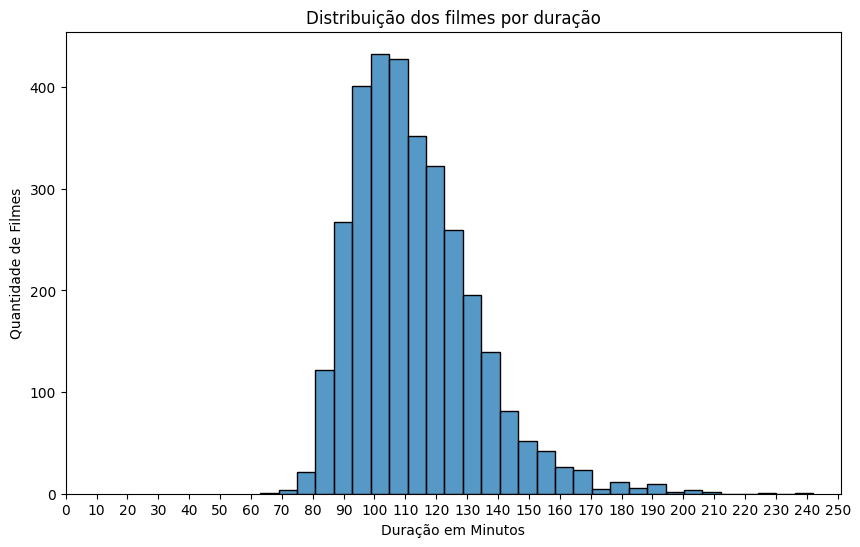

In [15]:
# Passo 1
plt.figure(figsize=(10, 6))

# Passo 2
sns.histplot(df['runtimeMinutes'], bins=30, kde=False)

# Passo 3
plt.title('Distribuição dos filmes por duração')
plt.xlabel('Duração em Minutos')
plt.ylabel('Quantidade de Filmes')

# Passo 4
plt.xticks(np.arange(0, 260, 10))

# Passo 5
plt.show()


---

## Tarefa 12: Boxplots de Variáveis Numéricas

**Objetivo:** Criar boxplots para identificar outliers e entender a distribuição de cada variável numérica.

### Contexto: O que é um Boxplot?
Um boxplot mostra:
- **Mediana** (linha central)
- **Quartis** (Q1 e Q3 - caixa)
- **Valores extremos** (whiskers)
- **Outliers** (pontos fora dos whiskers)

**O que você precisa fazer:**

**Passo 1:** Definir as colunas numéricas
- Crie uma lista com: `'runtimeMinutes'`, `'averageRating'`, `'numVotes'`, `'budget'`, `'gross'`
- Armazene em `numeric_columns`

**Passo 2:** Configurar o tamanho da figura
- `plt.figure(figsize=(15, 10))`

**Passo 3:** Dentro do loop fornecido:
- Crie o boxplot com `sns.boxplot()`
  - Parâmetro: `y=df[column].dropna()` - dados sem valores nulos
- Adicione título: `plt.title(f'Boxplot de {column}')`
- Adicione rótulo do eixo X: `plt.xlabel(column)`

**Passo 4:** Ajustar o layout e exibir
- `plt.tight_layout()`: ajusta automaticamente o espaçamento
- `plt.show()`

**O que observar:**
- Quais variáveis têm mais outliers?
- Qual é a amplitude dos valores em cada variável?

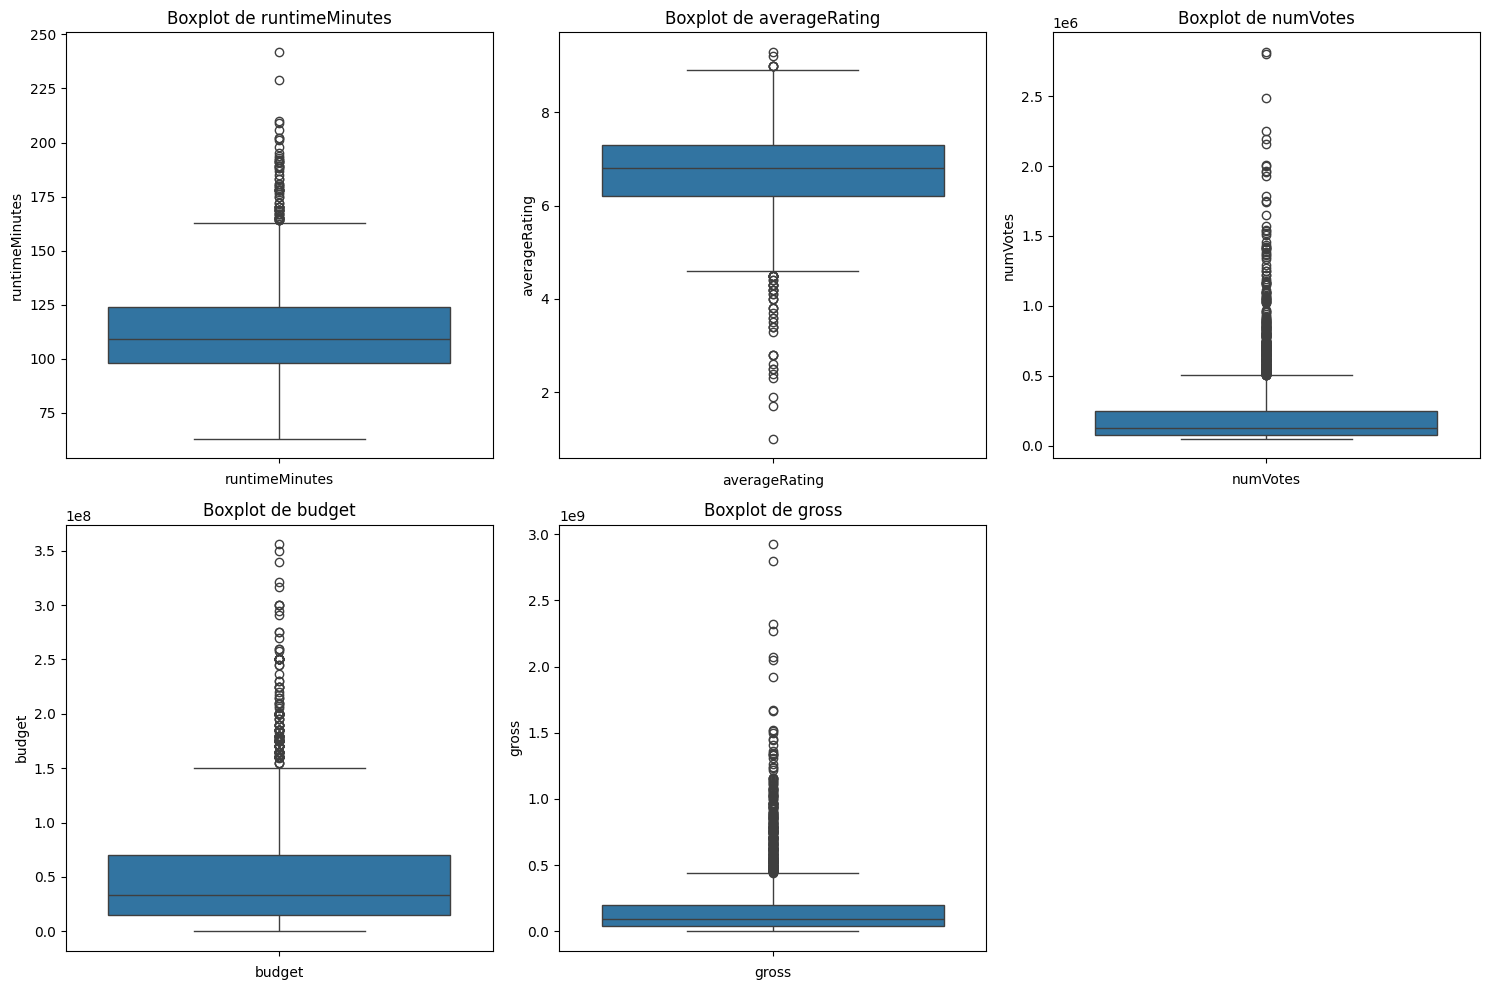

In [16]:
# Passo 1
numericas = ['runtimeMinutes', 'averageRating', 'numVotes', 'budget', 'gross']

# Passo 2
plt.figure(figsize=(15, 10))

# Loop
for i, column in enumerate(numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[column].dropna())
    plt.title(f'Boxplot de {column}')
    plt.xlabel(column)

# Passo 4
plt.tight_layout()
plt.show()


---

## Tarefa 13: Análise de ROI (Return on Investment)

**Objetivo:** Calcular o ROI dos filmes e categorizar em níveis de desempenho financeiro.

### Contexto: O que é ROI?
ROI (Retorno sobre Investimento) = (Receita - Investimento) / Investimento

Categorias de ROI:
- **Prejuízo**: ROI < -10% (perda superior a 10%)
- **Se Pagou**: -10% ≤ ROI ≤ 10% (recuperou o investimento)
- **Lucro (≤100%)**: 10% < ROI ≤ 100%
- **Lucro (>100%)**: ROI > 100%

**O que você precisa fazer:**

**Passo 1:** Calcular o ROI
- Crie uma nova coluna `'roi'`
- Fórmula: `(df['gross'] - df['budget']) / df['budget']`

**Passo 2:** Categorizar o ROI
- Use a função `pd.cut()` para criar categorias
- Parâmetros:
  - `x=df['roi']`: valores a categorizar
  - `bins=[-np.inf, -0.1, 0.1, 1, np.inf]`: limites das categorias
  - `labels=['Prejuízo', 'Se Pagou', 'Lucro (<=100%)', 'Lucro (>100%)']`
- Armazene em `roi_categories`

**Passo 3:** Contar filmes por categoria
- Use `.value_counts()` em `roi_categories`
- Use `.sort_index()` para ordenar
- Armazene em `roi_counts`

**Passo 4:** Configurar figura
- `plt.figure(figsize=(10, 6))`

**Passo 5:** Criar gráfico de barras
- Função: `sns.barplot()`
- Parâmetros:
  - `x=roi_counts.index`: categorias
  - `y=roi_counts.values`: quantidades

**Passo 6:** Adicionar título e rótulos
- `plt.title()`: 'Contagem de filmes por ROI'
- `plt.xlabel()`: 'Categoria ROI'
- `plt.ylabel()`: 'Número de Filmes'

**Passo 7:** Exibir o gráfico

**O que observar:**
- A maioria dos filmes dá lucro ou prejuízo?
- Quantos filmes têm ROI excepcional (>100%)?

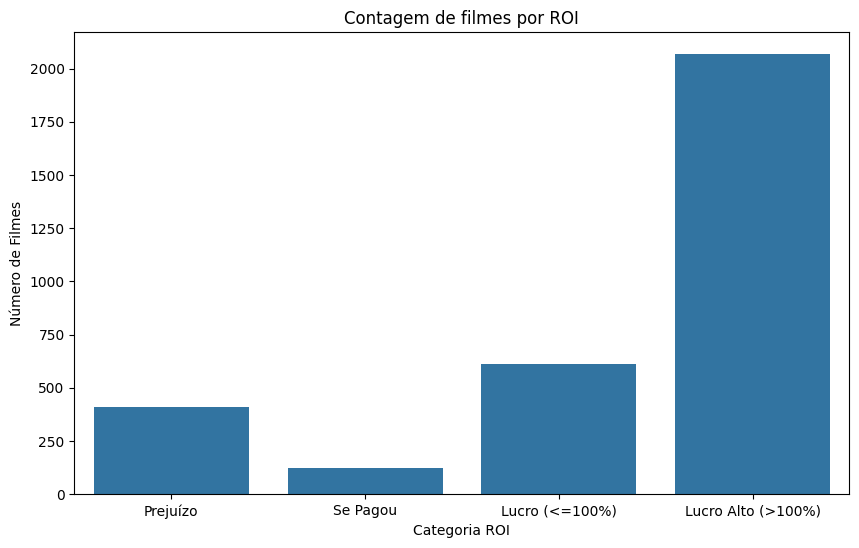

In [17]:
# ROI
df['ROI'] = (df['gross'] - df['budget']) / df['budget']

# Categorias
roi_categories = pd.cut(
    x=df['ROI'],
    bins=[-np.inf, -0.1, 0.1, 1, np.inf],
    labels=['Prejuízo', 'Se Pagou', 'Lucro (<=100%)', 'Lucro Alto (>100%)']
)

# Contagem
roi_counts = roi_categories.value_counts().sort_index()

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=roi_counts.index, y=roi_counts.values)

plt.title('Contagem de filmes por ROI')
plt.xlabel('Categoria ROI')
plt.ylabel('Número de Filmes')

plt.show()

---

## Tarefa 14: Análise de Filmes BlockBuster (Maiores Faturamentos)

**Objetivo:** Analisar o ROI dos filmes que mais faturaram (BlockBusters), pois grandes produções têm dinâmica financeira diferente.

### Contexto:
Filmes BlockBuster são grandes produções de estúdios famosos que geralmente têm alto orçamento e expectativa de grande retorno. Queremos analisar o ROI especificamente desses filmes de maior faturamento.

**O que você precisa fazer:**

**Passo 1:** Ordenar o DataFrame por faturamento e ROI
- Use `.sort_values()` no DataFrame
- Parâmetros:
  - `by=['gross', 'roi']`: primeiro por gross, depois por roi
  - `ascending=False`: ordem decrescente
- Armazene em `df_sorted`

**Passo 2:** Visualizar os 10 primeiros
- Use `.head(10)` em `df_sorted` para ver os dados

**Passo 3:** Selecionar top 10 e reordenar por ROI
- Pegue as 10 primeiras linhas: `df_sorted.head(10)`
- Reordene por ROI: `.sort_values(by='roi', ascending=False)`
- Armazene em `top_10`

**Passo 4:** Configurar figura
- `plt.figure(figsize=(12, 8))`

**Passo 5:** Criar subplot para o gráfico de barras
- Use `plt.subplot(2, 1, 2)` - 2 linhas, 1 coluna, segundo subplot

**Passo 6:** Criar gráfico de barras horizontal
- `sns.barplot()`:
  - `x='roi'`
  - `y='primaryTitle'`
  - `data=top_10`
  - `palette='viridis'`

**Passo 7:** Adicionar título e rótulos
- `plt.title()`: 'Top 10 Filmes BlockBusters por ROI'
- `plt.xlabel()`: 'ROI'
- `plt.ylabel()`: '' (vazio)

**Passo 8:** Ajustar layout e exibir
- `plt.tight_layout()`
- `plt.show()`

**O que observar:**
- Os filmes que mais faturam necessariamente têm o melhor ROI?
- BlockBusters têm ROI consistente ou varia muito?

/tmp/ipykernel_8317/2877338213.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ROI', y='primaryTitle', data=top_10, palette='viridis')


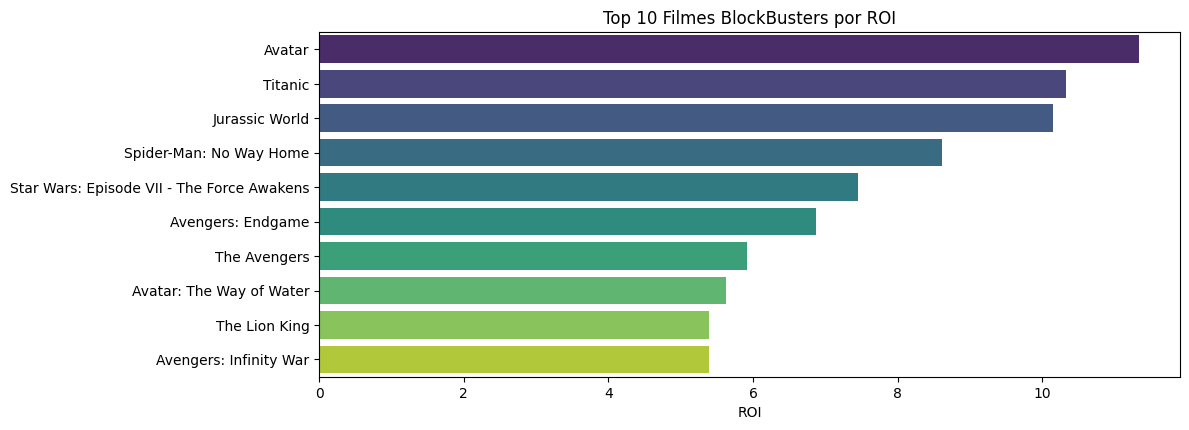

In [18]:
# Passo 1
df_sorted = df.sort_values(by=['gross', 'ROI'], ascending=False)

# Passo 2
df_sorted.head(10)

# Passo 3
top_10 = df_sorted.head(10).sort_values(by='ROI', ascending=False)

# Passo 4
plt.figure(figsize=(12, 8))

# Passo 5
plt.subplot(2, 1, 2)

# Passo 6
sns.barplot(x='ROI', y='primaryTitle', data=top_10, palette='viridis')

# Passo 7
plt.title('Top 10 Filmes BlockBusters por ROI')
plt.xlabel('ROI')
plt.ylabel('')

# Passo 8
plt.tight_layout()
plt.show()



---

## Conclusão da Análise


### Próximos Passos:

- Experimente criar suas próprias análises
- Teste diferentes parâmetros de visualização
- Explore outras relações entre variáveis
- Crie hipóteses e teste-as com os dados

### Dicas Finais:

- Sempre documente seu código
- Use nomes de variáveis descritivos
- Organize seu notebook em seções lógicas
- Complemente visualizações com interpretações
- Questione os dados e busque insights

---